# Derivative-of-Gaussian Kernel Analysis

This notebook implements and compares different versions of the Derivative-of-Gaussian (DoG) kernel for discrete-time derivative estimation, based on the formulas from `root.tex`.

## Import Libraries

In [383]:
import numpy as np
import matplotlib.pyplot as plt
from AlgDiff import *
save_to_disk = False

font_increase = 5

# Enable LaTeX rendering for matplotlib
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12 +font_increase  # Default font size
plt.rcParams['axes.labelsize'] = 12 +font_increase  # Axis labels
plt.rcParams['axes.titlesize'] = 14 +font_increase  # Title
plt.rcParams['xtick.labelsize'] = 10 +font_increase  # X-axis ticks
plt.rcParams['ytick.labelsize'] = 10 +font_increase  # Y-axis ticks
plt.rcParams['legend.fontsize'] = 11 +font_increase  # Legend

## Input Parameters

Set the cutoff frequency and sampling frequency. All other parameters are derived from these.

In [384]:
f_cut = 2  # Cutoff frequency in Hz
f_s = 20  # Sampling frequency in Hz
freq = 1  # Hz (frequency of sine wave for testing)
noise_fraction = 0.0 # 0.02 -> +-2% of signal amplitude added noise
noise_base = 0.05  # Base noise level

# DoG params
pm_std_gaussian = 6
sigma_scale = np.sqrt(2.0* np.log(2)) # 1  # np.sqrt(2*np.log(2))

# AlgeDiff params
alpha_alge = 4.0
beta_alge = 4.0
N_alge = 1

## Calculate Derived Parameters

From the paper formulas:
- $\sigma = \frac{1}{2\pi f_{\text{cut}}}$
- $N = 2K+1 = \lceil 6\sigma f_s \rceil$

In [385]:


# sigma = 1 / (2 * pi * f_cut)
#sigma = 1 / (2 * np.pi * f_cut)
sigma = sigma_scale / (2 * np.pi * f_cut)
# N = int(ceil(6 * sigma * f_s))
N = int(np.ceil(pm_std_gaussian * sigma * f_s))

# Ensure N is odd (2K+1 form)
if N % 2 == 0:
    N += 1

K = (N - 1) // 2  # Half-window size
dt = 1 / f_s  # Time step

print(f"Input Parameters:")
print(f"  f_cut = {f_cut:.2f} Hz")
print(f"  f_s = {f_s} Hz")
print(f"\nDerived Parameters:")
print(f"  sigma = {sigma:.6f}")
print(f"  N = {N} (window size)")
print(f"  K = {K} (half-window)")
print(f"  delay = {K*dt} s")

Input Parameters:
  f_cut = 2.00 Hz
  f_s = 20 Hz

Derived Parameters:
  sigma = 0.093695
  N = 13 (window size)
  K = 6 (half-window)
  delay = 0.30000000000000004 s


## Non-Causal Kernel

Symmetric kernel centered at k=0:

$$h[k] = -\frac{t_k}{\sigma^3 \sqrt{2\pi}} \exp\left(-\frac{t_k^2}{2\sigma^2}\right) \cdot \Delta t$$

where $t_k = k \cdot \Delta t$ for $k \in [-K, K]$

In [386]:
k_noncausal = np.arange(-K, K + 1)  # k in [-K, K]
t_k = k_noncausal * dt

# h[k] = -(t_k / (sigma^3 * sqrt(2*pi))) * exp(-t_k^2 / (2*sigma^2))
# Multiply by dt to account for discrete approximation of the integral
h_noncausal = -(t_k / (sigma**3 * np.sqrt(2 * np.pi))) * np.exp(-t_k**2 / (2 * sigma**2)) * dt

## Causal Kernel Versions

We create multiple versions of the causal kernel to compare their performance:

1. **Truncated + Normalized**: The paper version with mean centering and L2 normalization
2. **Truncated Raw**: Just mean centering, no L2 normalization
3. **Shifted**: The non-causal kernel shifted by K samples (delayed but not truncated)

In [387]:
# First create h_c[k] = h[-k] for k in [0, 2K]
k_causal_raw = np.arange(0, 2*K + 1)  # k in [0, 2K]
t_k_causal_raw = -k_causal_raw * dt  # We use h[-k], so negative time

h_causal_raw = -(t_k_causal_raw / (sigma**3 * np.sqrt(2 * np.pi))) * np.exp(-t_k_causal_raw**2 / (2 * sigma**2)) * dt

# Shifted non-causal kernel (no truncation)
h_causal_shifted = h_noncausal.copy()


# Just smoothing with half kernel size (only past values available)
h_tim = np.exp(-t_k_causal_raw**2 / (2.0 * sigma**2))
h_tim_sum = np.sum(h_tim)
for i,x in enumerate(h_tim):
    h_tim[i] /= h_tim_sum

## Algebraic Differentiator

The kernel for estimating the $n$-th derivative using an algebraic differentiator is given by:

$$h_n(t) = \frac{d^n}{dt^n} g_0(t)$$

where $g_0(t)$ is the **integral kernel** (derivative estimator of order 0):

$$g_0(t) = \frac{1}{T} w\left(\frac{2t}{T}\right) \sum_{k=0}^{N} \lambda_k^{(0)} P_k^{(\alpha,\beta)}\left(\frac{2t}{T} - 1\right)$$

with:

$$w(\tau) = (1-\tau^2)^\alpha (1+\tau)^\beta = \left(1 - \left(\frac{2t}{T} - 1\right)^2\right)^\alpha \left(1 + \frac{2t}{T} - 1\right)^\beta$$

for $t \in [0, T]$ and zero elsewhere.

### Parameters

| Parameter | Description |
|-----------|-------------|
| $T$ | **Window length** - determines the time interval over which the kernel is non-zero |
| $\alpha$ | **Shape parameter** - controls smoothness and stopband slope. Higher values → smoother kernel. Must satisfy $\alpha > n-1$ |
| $\beta$ | **Shape parameter** - controls smoothness and stopband slope. Higher values → smoother kernel. Must satisfy $\beta > n-1$ |
| $N$ | **Truncation order** - number of terms in the Jacobi polynomial series. Higher $N$ → better polynomial exactness |
| $P_k^{(\alpha,\beta)}(x)$ | **Jacobi polynomials** - orthogonal polynomials with respect to weight function $(1-x)^\alpha(1+x)^\beta$ |
| $\lambda_k^{(0)}$ | **Fourier coefficients** - computed from orthogonality relations of Jacobi polynomials |
| $n$ | **Derivative order** - order of derivative to estimate (1 for first derivative, 2 for second, etc.) |

### Key Properties

- **Cutoff frequency**: $\omega_c = \frac{2\pi c_{\alpha,\beta}}{T}$ where $c_{\alpha,\beta}$ depends on $\alpha, \beta$
- **Stopband slope**: $20(\mu+1)$ dB/decade where $\mu = \min\{\alpha, \beta\}$
- **Degree of exactness**: The differentiator exactly differentiates polynomials up to degree $\gamma = n + N + 1$
- **Delay**: For $N \geq 1$, the delay parameter $\theta$ is set to the largest root of $P_{N+1}^{(\alpha,\beta)}$ to minimize delay

### First Derivative Kernel (Simplified)

For the first derivative ($n=1$):

$$h_1(t) = \frac{d}{dt} g_0(t) = \frac{2}{T^2} w'\left(\frac{2t}{T}\right) \sum_{k=0}^{N} \lambda_k^{(0)} P_k^{(\alpha,\beta)}\left(\frac{2t}{T} - 1\right) + \frac{2}{T^2} w\left(\frac{2t}{T}\right) \sum_{k=0}^{N} \lambda_k^{(0)} P_k'^{(\alpha,\beta)}\left(\frac{2t}{T} - 1\right)$$

where $P_k'^{(\alpha,\beta)}$ denotes the derivative of the Jacobi polynomial.

### Typical Values for Gaussian-like Behavior

For a smooth, Gaussian-like kernel similar to DoG:
- $\alpha = \beta = 2$ (smooth, bell-shaped)
- $N = 2$ or $3$ (good polynomial exactness)
- $T = \frac{6}{\omega_c} = \frac{3}{\pi f_c}$ (similar to $6\sigma$ for Gaussian)


In [388]:
wc_alge = 2 * np.pi * f_cut # cut frequency in rad/s

# Create algebraic differentiator
myAlgeDif = AlgebraicDifferentiator(
    ts=dt,
    alpha=alpha_alge,
    beta=beta_alge,
    N=N_alge,  # Set N=0 for fully symmetric kernel (will shift manually)
    T=None,
    wc=wc_alge,
    display=False,
    corr=True
)

# Discretize to get kernel coefficients
myAlgeDif.discretize(der=0, method='mid-point')

# Get only the kernel we will shift and apply convolution manually
h_alge = myAlgeDif._AlgebraicDifferentiator__w[0]['mid-point']

## Plot: Kernel Comparison


Saved kernel comparison plot to kernel_comparison.eps


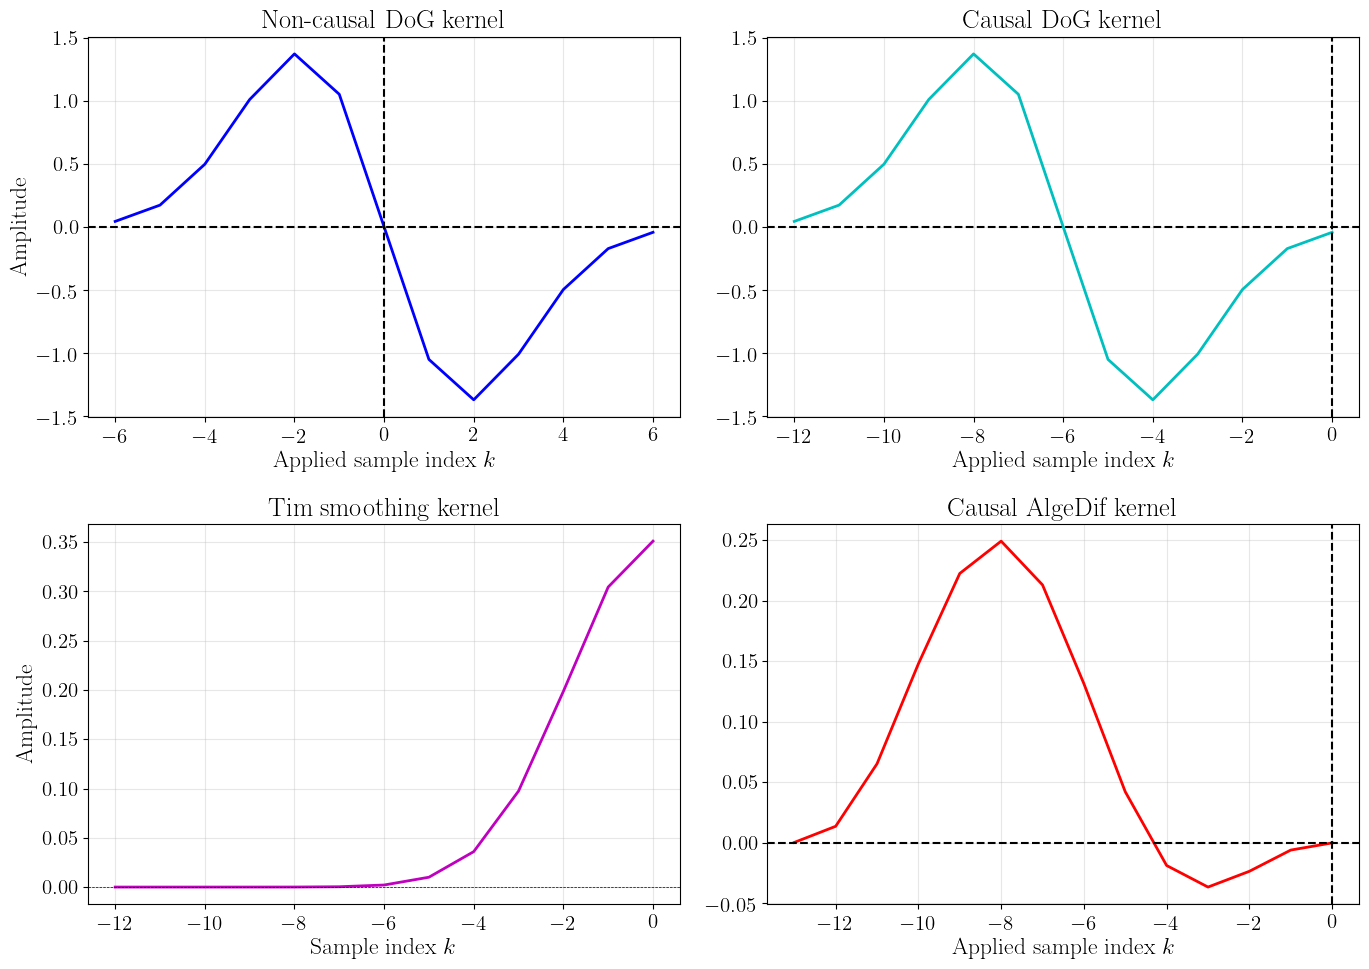

In [389]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
#fig, (ax1, ax2, ax4) = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Non-causal kernel
ax1.plot(k_noncausal, h_noncausal, 'b-', linewidth=2)
ax1.axhline(y=0, color='k', linestyle='--', linewidth=1.5)
ax1.axvline(x=0, color='k', linestyle='--', linewidth=1.5)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Applied sample index $k$')
ax1.set_ylabel('Amplitude')
ax1.set_title(f'Non-causal DoG kernel')

# Causal kernel (shifted, not truncated)
ax2.plot(-(k_noncausal + K), -h_causal_shifted, 'c-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', linewidth=1.5)
ax2.axvline(x=0, color='k', linestyle='--', linewidth=1.5)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Applied sample index $k$')
#a2.set_ylabel('Amplitude')
ax2.set_title('Causal DoG kernel')

# AlgeDif kernel
# Create indices for h_alge
K_alge = (len(h_alge) - 1) // 2
k_alge = np.arange(-(len(h_alge)-1), 1)

# Causal kernel (raw, no normalization)
ax3.plot(-k_causal_raw, h_tim, 'm-', linewidth=2)
ax3.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('Sample index $k$')
ax3.set_ylabel('Amplitude')
ax3.set_title('Tim smoothing kernel')

ax4.plot(k_alge, h_alge, 'r-', linewidth=2)
ax4.axvline(x=0, color='k', linestyle='--', linewidth=1.5)
ax4.axhline(y=0, color='k', linestyle='--', linewidth=1.5)
ax4.grid(True, alpha=0.3)
ax4.set_xlabel('Applied sample index $k$')
#ax4.set_ylabel('Amplitude')
ax4.set_title('Causal AlgeDif kernel')

plt.tight_layout()
if save_to_disk:
    plt.savefig('/home/fabi/catkin_ws/src/ros_imu_calib/pub/img/kernel_comparison.eps', format='eps', dpi=600)
print("\nSaved kernel comparison plot to kernel_comparison.eps")
plt.show()

## Generate Test Signal

Create a sine wave and compute its analytical derivative for comparison.

In [390]:
# Create a clean decaying sine wave sampled at 200 Hz
# x_clean(t) = e^{-t/3} sin(2*pi*f*t)
duration = 7.0  # seconds
t = np.arange(0, duration, dt)
x_clean = np.sin(2 * np.pi * freq * t) * np.exp(-t / 3)

# Add signal-dependent noise (±2% of signal amplitude + base noise 0.01)
np.random.seed(42)  # For reproducibility
noise = (noise_fraction * np.abs(x_clean) + noise_base) * np.random.randn(len(t))
x = x_clean + noise

# Analytical derivative: d/dt[e^{-t/3} sin(2*pi*f*t)]
dx_dt_true = np.exp(-t / 3) * (
    2 * np.pi * freq * np.cos(2 * np.pi * freq * t)
    - (1.0 / 3.0) * np.sin(2 * np.pi * freq * t)
)

## Functions to assess noise level, causal finite differences, and causal lowpass filter

### Noise Level Estimation

The `get_noise_level` function computes a scalar metric to quantify noise amplitude using three different modes:

**Median mode (default):**
$$\text{noise}_{\text{median}} = \text{median}(|x|)$$

**Max mode:**
$$\text{noise}_{\text{max}} = \max(|x|)$$

**RMS mode:**
$$\text{noise}_{\text{rms}} = \sqrt{\sum_{i} x_i^2}$$

The median mode is robust to outliers, max mode captures peak deviations, and RMS mode gives the total energy.

---

### Backward Finite Differences (Fornberg's Algorithm)

The `backward_diff` function computes causal derivatives using only past samples via Fornberg's algorithm, which generates optimal finite-difference coefficients.

**General form:**
$$f'[n] \approx \frac{1}{\Delta t} \sum_{k=0}^{p} c_k \cdot f[n-k]$$

where:
- $p$ is the order (number of backward points)
- $c_k$ are coefficients computed via Fornberg's algorithm for grid points $x_k = -k$ (i.e., $0, -1, -2, \ldots, -p$)
- The evaluation point is $z = 0$ (current time)

**Adaptive order for initial samples:**
For samples where $n < p$, the effective order is reduced:
$$p_{\text{eff}}[n] = \min(n, p)$$

This ensures causality: at $n=0$, no past samples exist, so $f'[0] = 0$.

**Example (3rd-order):**
For $p=3$, Fornberg's algorithm yields:
$$f'[n] \approx \frac{11f[n] - 18f[n-1] + 9f[n-2] - 2f[n-3]}{6\Delta t}$$

---

### Causal Lowpass Filter (1st-Order Exponential)

The `lowpass_filter` function implements a causal 1st-order IIR lowpass filter with cutoff frequency $f_{\text{cut}}$.

**Filter coefficient:**
$$c = \cos\left(\frac{2\pi f_{\text{cut}}}{f_{\text{sample}}}\right)$$

$$\alpha = \sqrt{c^2 - 4c + 3} + c - 1$$

**Recursive update equation:**
$$y[i] = y[i-1] - \alpha \left(y[i-1] - x[i]\right)$$

with initial condition $y[0] = 0$.

This can be rewritten as:
$$y[i] = (1 - \alpha)y[i-1] + \alpha x[i]$$

which is a standard exponential moving average (EMA) with smoothing factor $\alpha$. The parameter $\alpha$ is designed such that the filter's -3dB cutoff frequency matches $f_{\text{cut}}$.

### Causal lowpass (-6dB)

$$\alpha = \frac{c-1+\sqrt{c^2-8c+7}}{3},\quad c=\cos\left(\frac{2\pi f_\text{cut}}{f_s}\right)$$

In [391]:
"""
Noise level function

parameters:
data: the data
mode: chose from [median, max, rms]

returns:
noise level (scalar)
"""
def get_noise_level(data, mode='max'):
    if mode == 'median':
        return np.median(np.abs(data))
    elif mode == 'max':
        return np.max(np.abs(data))
    elif mode == 'rms':
        return np.sqrt(np.sum(data**2))
    else:
        print(f"Mode {mode} not defined. Using median!")
        return np.median(np.abs(data))

def get_backward_diff_coeffs(order):
    """
    Calculate backward finite-difference coefficients for 1st derivative.
    
    Uses Fornberg's algorithm to compute weights for:
    f'[n] ≈ (c_0*f[n] + c_1*f[n-1] + ... + c_order*f[n-order]) / dt
    
    Parameters:
    -----------
    order : int
        Number of backward points to use (order >= 1)
    
    Returns:
    --------
    numpy array of shape (order+1,)
        Coefficients [c_0, c_1, ..., c_order]
    """
    # Fornberg's algorithm for finite difference weights
    n = order
    m = 1  # First derivative
    z = 0.0  # Evaluation point
    x = np.array([float(-i) for i in range(n + 1)])  # Grid: 0, -1, -2, ...
    
    # Initialize
    c = np.zeros((m + 1, n + 1, n + 1))
    c[0, 0, 0] = 1.0
    c1 = 1.0
    
    for i in range(1, n + 1):
        mn = min(i, m)
        c2 = 1.0
        for j in range(i):
            c3 = x[i] - x[j]
            c2 = c2 * c3
            for k in range(mn, -1, -1):
                c[k, i, j] = ((x[i] - z) * c[k, i-1, j] - 
                             (k * c[k-1, i-1, j] if k >= 1 else 0.0)) / c3
        
        for k in range(mn, -1, -1):
            c[k, i, i] = (c1 / c2) * ((k * c[k-1, i-1, i-1] if k >= 1 else 0.0) - 
                                     (x[i-1] - z) * c[k, i-1, i-1])
        c1 = c2
    
    # Extract first derivative coefficients
    weights = c[1, n, :]
    
    return weights

def backward_diff(x, dt, order=1):
    """
    Causal backward finite differences using only past samples.
    
    Parameters:
    -----------
    x : array-like
        Input signal
    dt : float
        Time step
    order : int
        Accuracy order (any positive integer)
    
    Returns:
    --------
    array
        Derivative estimate with progressively increasing order for initial samples
    """
    n_samples = len(x)
    result = np.zeros_like(x)
    
    # For initial samples, use progressively increasing order
    for n in range(n_samples):
        available_order = min(n, order)
        if available_order == 0:
            result[n] = 0.0  # No past samples available
        else:
            coeffs = get_backward_diff_coeffs(available_order)
            acc = 0.0
            for k in range(available_order + 1):
                acc += coeffs[k] * x[n - k]
            result[n] = acc / dt
    
    return result

def backward_diff2(x, dt, order=1):
    """
    Causal backward finite differences using hardcoded formulas (orders 1-10).
    
    Parameters:
    -----------
    x : array-like
        Input signal
    dt : float
        Time step
    order : int
        Accuracy order (1-10)
    
    Returns:
    --------
    array
        Derivative estimate with causal padding
    """
    if order == 1:
        return np.r_[0.0, np.diff(x)] / dt
    if order == 2:
        # 2nd-order: (3x[n]-4x[n-1]+x[n-2])/(2dt)
        return np.r_[0.0, 0.0, (3*x[2:] - 4*x[1:-1] + x[:-2]) / (2*dt)]
    if order == 3:
        # 3rd-order: (11x[n]-18x[n-1]+9x[n-2]-2x[n-3])/(6dt)
        return np.r_[0.0, 0.0, 0.0, (11*x[3:] - 18*x[2:-1] + 9*x[1:-2] - 2*x[:-3]) / (6*dt)]
    if order == 4:
        # 4th-order: (25x[n]-48x[n-1]+36x[n-2]-16x[n-3]+3x[n-4])/(12dt)
        return np.r_[0.0, 0.0, 0.0, 0.0, (25*x[4:] - 48*x[3:-1] + 36*x[2:-2] - 16*x[1:-3] + 3*x[:-4]) / (12*dt)]
    if order == 5:
        # 5th-order: (137x[n]-300x[n-1]+300x[n-2]-200x[n-3]+75x[n-4]-12x[n-5])/(60dt)
        return np.r_[0.0, 0.0, 0.0, 0.0, 0.0, (137*x[5:] - 300*x[4:-1] + 300*x[3:-2] - 200*x[2:-3] + 75*x[1:-4] - 12*x[:-5]) / (60*dt)]
    if order == 6:
        # 6th-order: (49x[n]-120x[n-1]+150x[n-2]-120x[n-3]+45x[n-4]-12x[n-5]+x[n-6])/(20dt)
        return np.r_[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (49*x[6:] - 120*x[5:-1] + 150*x[4:-2] - 120*x[3:-3] + 45*x[2:-4] - 12*x[1:-5] + x[:-6]) / (20*dt)]
    if order == 7:
        # 7th-order
        return np.r_[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (363*x[7:] - 1140*x[6:-1] + 1890*x[5:-2] - 1920*x[4:-3] + 1215*x[3:-4] - 486*x[2:-5] + 105*x[1:-6] - 10*x[:-7]) / (140*dt)]
    if order == 8:
        # 8th-order
        return np.r_[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (761*x[8:] - 2688*x[7:-1] + 5208*x[6:-2] - 6720*x[5:-3] + 5580*x[4:-4] - 3120*x[3:-5] + 1008*x[2:-6] - 168*x[1:-7] + 11*x[:-8]) / (280*dt)]
    if order == 9:
        # 9th-order
        return np.r_[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (7129*x[9:] - 28560*x[8:-1] + 66528*x[7:-2] - 99456*x[6:-3] + 101745*x[5:-4] - 71280*x[4:-5] + 31920*x[3:-6] - 9072*x[2:-7] + 1386*x[1:-8] - 84*x[:-9]) / (2520*dt)]
    if order == 10:
        # 10th-order
        return np.r_[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (7381*x[10:] - 32400*x[9:-1] + 85680*x[8:-2] - 143712*x[7:-3] + 164205*x[6:-4] - 133848*x[5:-5] + 71280*x[4:-6] - 25920*x[3:-7] + 6480*x[2:-8] - 900*x[1:-9] + 49*x[:-10]) / (2520*dt)]
    raise ValueError('order must be between 1 and 10')

def lowpass_filter(x, f_cut, f_sample):
    """Causal 1st-order lowpass using alpha from cutoff/sample frequency."""
    c = np.cos(2 * np.pi * f_cut / f_sample)
    alpha = np.sqrt(c * c - 4 * c + 3) + c - 1 # 3dB cutoff
    #alpha = (np.sqrt(c * c - 8 * c + 7) + c - 1) / 3 # 6dB cutoff
    y = np.zeros_like(x)
    smoothed = 0.0
    for i, xi in enumerate(x):
        smoothed = smoothed - alpha * (smoothed - xi)
        y[i] = smoothed
    return y

# print("Fornberg:", get_backward_diff_coeffs(3))
# print("Expected:", np.array([11, -18, 9, -2]) / 6)

## Apply Convolution

Implement the convolution using explicit loops:

**Non-causal:**
$$\frac{\partial x[n]}{\partial t} = \sum_{k=-K}^{K} h[k] \cdot x[n-k]$$

**Causal:**
$$\frac{\partial x[n]}{\partial t} = \sum_{k=-K}^{K} h[k] \cdot x[n-k-K]$$



Saved Tim smoothing effect plot to tim_smoothing_effect.eps


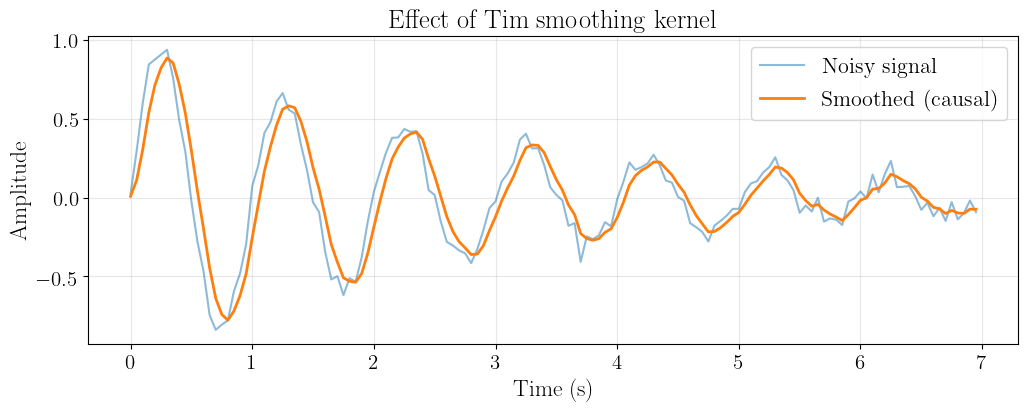

In [392]:
def convolve(data, kernel):
    """
    Convolution function

    parameters:
    data: numpy array of shape (N, 4) with first column timestamps, next three columns data to be convolved
    kernel: 1D numpy array with convolution kernel (should have odd length)

    returns:
    numpy array of shape (N, 4) with first column timestamps, next three columns convolved data
    """
    res = np.zeros_like(data)
    K = (len(kernel) - 1) // 2 # floor division
    for n in range(len(data)):
        for k in range(-K, K + 1):
            idx = n - k - K  # Shift by K to make it causal
            if 0 <= idx < len(data):
                res[n] += kernel[k + K] * data[idx]
    return res

def convolve_noncausal(data, kernel):
    """
    Non-causal convolution function
    
    parameters:
    data: numpy array of shape (N, 4) with first column timestamps, next three columns data to be convolved
    kernel: 1D numpy array with convolution kernel (should have odd length)
    
    returns:
    numpy array of shape (N, 4) with first column timestamps, next three columns convolved data
    """
    res = np.zeros_like(data)
    K = (len(kernel) - 1) // 2  # floor division
    for n in range(len(data)):
        for k in range(-K, K + 1):
            idx = n - k  # No shift for non-causal
            if 0 <= idx < len(data):
                res[n] += kernel[k + K] * data[idx]
    return res


# Apply convolutions using the convolve function
dx_dt_noncausal = convolve_noncausal(x, h_noncausal)
# dx_dt_causal = convolve(x, h_causal)
# dx_dt_causal_unnorm = convolve(x, h_causal_unnormalized)
dx_dt_causal_shifted = convolve(x, h_causal_shifted)

# Finite differences (central) for comparison
dx_dt_fd = backward_diff(x, dt)

# AlgeDif kernel
dx_dt_alge = convolve(x, h_alge)

# Tim kernel smoothing
x_smooth_tim_causal = convolve(x, h_tim)
x_smooth_tim_noncausal = convolve_noncausal(x, h_tim)

# Plot x_smooth_tim_causal and x_smooth_tim_noncausal to see the effect of smoothing
plt.figure(figsize=(12, 4))
plt.plot(t, x, label='Noisy signal', alpha=0.5)
plt.plot(t, x_smooth_tim_causal, label='Smoothed (causal)', linewidth=2)
# plt.plot(t, x_smooth_tim_noncausal, label='Smoothed (non-causal)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Effect of Tim smoothing kernel')
plt.legend()
plt.grid(True, alpha=0.3)
if save_to_disk:
    plt.savefig('/home/fabi/catkin_ws/src/ros_imu_calib/pub/img/tim_smoothing_effect.eps', format='eps', dpi=600)
print("\nSaved Tim smoothing effect plot to tim_smoothing_effect.eps")
plt.show()

## Plot: Derivative Comparison

Saved derivative comparison plot to derivative_comparison.eps


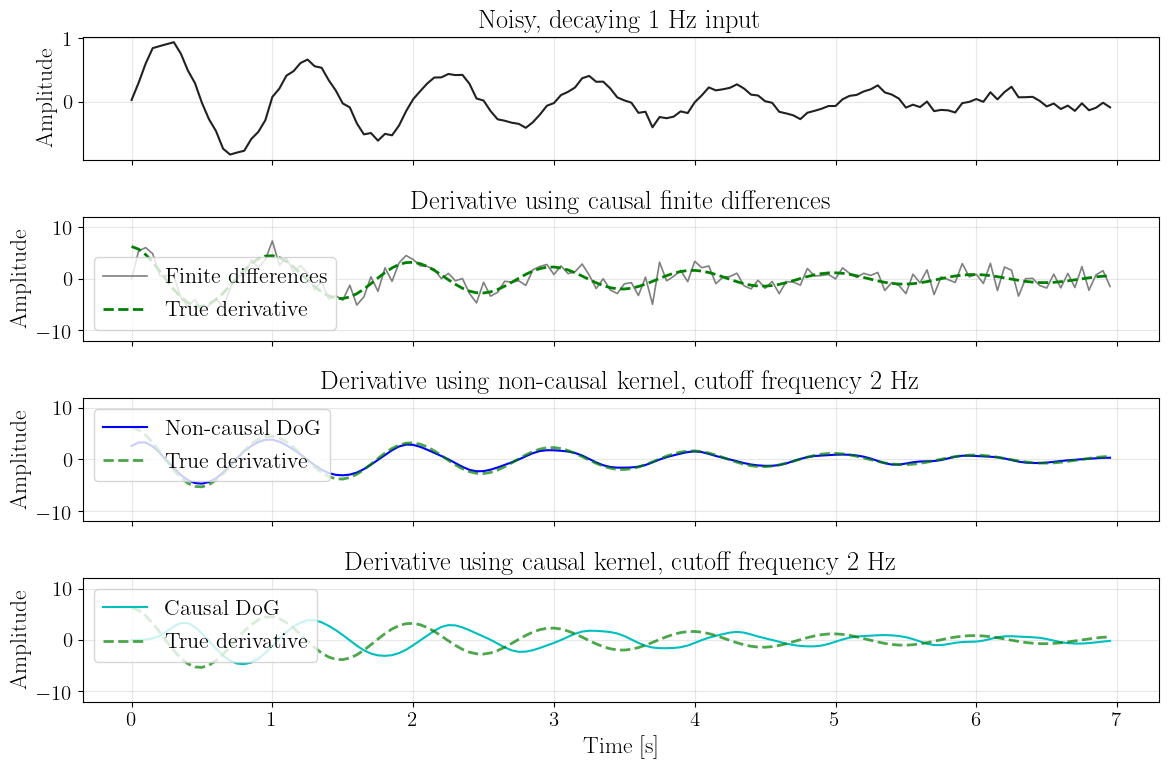

In [393]:
ax_lims = 12

fig, (ax1, ax2, ax5, ax6) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
#fig, (ax1, ax2, ax3, ax5, ax6) = plt.subplots(5, 1, figsize=(12, 8), sharex=True)

# Plot 1: Original signal (showing both clean and noisy)
ax1.plot(t, x, color='0.13')
ax1.grid(True, alpha=0.3)
#ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Amplitude')
ax1.set_title('Noisy, decaying 1~Hz input')

# Plot 2: Derivative using finite differences
ax2.plot(t, dx_dt_fd, color='0.5', linewidth=1.2, label='Finite differences')
ax2.plot(t, dx_dt_true, 'g--', linewidth=2, label='True derivative')
ax2.grid(True, alpha=0.3)
ax2.set_ylabel('Amplitude')
ax2.set_ylim([-ax_lims,ax_lims])
ax2.set_title(f'Derivative using causal finite differences')
ax2.legend()

# Plot 3: Derivative using algebraic differentiator
# ax3.plot(t, dx_dt_alge, 'r-', linewidth=1.5, label='AlgeDif')
# ax3.plot(t, dx_dt_true, 'g--', linewidth=2, alpha=0.7, label='True derivative')
# ax3.grid(True, alpha=0.3)
# #ax3.set_xlabel('Time [s]')
# ax3.set_ylim([-ax_lims,ax_lims])
# ax3.set_ylabel('Amplitude')
# ax3.set_title('Derivative using algebraic differentiator')
# ax3.legend()

# # Plot 4: Derivative using unnormalized causal kernel
# ax4.plot(t, dx_dt_true, 'g-', linewidth=2, alpha=0.7, label='True derivative (clean signal)')
# ax4.plot(t, dx_dt_causal_unnorm, 'm--', linewidth=1.5, label='Causal DoG on noisy signal (raw)')
# ax4.grid(True, alpha=0.3)
# ax4.set_xlabel('Time [s]')
# ax4.set_ylabel('Derivative')
# ax4.set_title('Derivative using Causal Kernel (truncated, no processing)')
# ax4.legend()

# Plot 5: Derivative using shifted (non-truncated) causal kernel
ax5.plot(t, dx_dt_noncausal, 'b-', linewidth=1.5, label='Non-causal DoG')
ax5.plot(t, dx_dt_true, 'g--', linewidth=2, alpha=0.7, label='True derivative')
ax5.grid(True, alpha=0.3)
#ax2.set_xlabel('Time [s]')
ax5.set_ylabel('Amplitude')
ax5.set_ylim([-ax_lims,ax_lims])
ax5.set_title(f'Derivative using non-causal kernel, cutoff frequency {f_cut} Hz')
ax5.legend()

ax6.plot(t, dx_dt_causal_shifted, 'c-', linewidth=1.5, label='Causal DoG')
ax6.plot(t, dx_dt_true, 'g--', linewidth=2, alpha=0.7, label='True derivative')
ax6.grid(True, alpha=0.3)
ax6.set_ylim([-ax_lims,ax_lims])
ax6.set_xlabel('Time [s]')
ax6.set_ylabel('Amplitude')
ax6.set_title(f'Derivative using causal kernel, cutoff frequency {f_cut} Hz')
ax6.legend()

plt.tight_layout()
if save_to_disk:
    plt.savefig('/home/fabi/catkin_ws/src/ros_imu_calib/pub/img/derivative_comparison.eps', format='eps', dpi=600)
print("Saved derivative comparison plot to derivative_comparison.eps")
plt.show()

## Phase Fit: Causal Derivative

Fit a cosine to the causal-kernel derivative and compute the phase shift versus the true derivative.

Phase shift (fitted vs true): -108.54 degrees
Time lag (fitted vs true): -0.301492 s


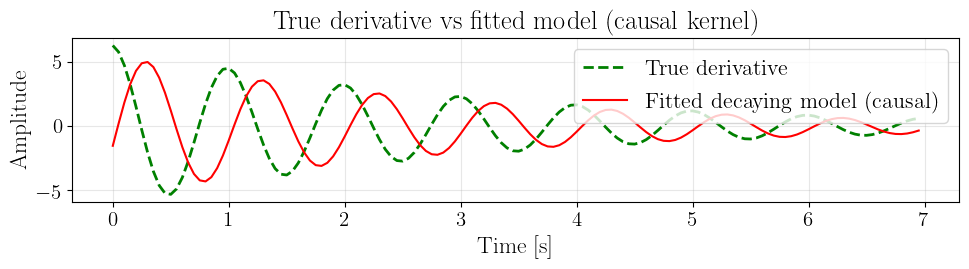

In [394]:
# Fit decaying sinusoid derivative to causal-kernel output and compute phase shift
omega = 2 * np.pi * freq

# Use central portion to avoid edge effects from convolution
start_idx = K
end_idx = len(t) - K if len(t) > 2 * K else len(t)
fit_slice = slice(start_idx, end_idx)

t_fit = t[fit_slice]
y_fit = dx_dt_causal_shifted[fit_slice]

# Linear least squares fit with decaying basis:
# y = e^{-t/3}*(a*cos(ωt) + b*sin(ωt)) + c
exp_decay = np.exp(-t_fit / 3)
X = np.column_stack([
    exp_decay * np.cos(omega * t_fit),
    exp_decay * np.sin(omega * t_fit),
    np.ones_like(t_fit)
])
coef, _, _, _ = np.linalg.lstsq(X, y_fit, rcond=None)
a, b, c = coef

A_fit = np.hypot(a, b)
phi_fit = np.arctan2(-b, a)  # a cos + b sin = A cos(ωt + phi)

# Reference phase from true derivative (same decaying basis)
coef_true, _, _, _ = np.linalg.lstsq(X, dx_dt_true[fit_slice], rcond=None)
a_true, b_true, _ = coef_true
phi_true = np.arctan2(-b_true, a_true)

# Phase shift (wrapped to [-pi, pi])
phase_shift = (phi_fit - phi_true + np.pi) % (2 * np.pi) - np.pi
phase_shift_deg = np.degrees(phase_shift)
phase_shift_time = phase_shift / omega

# Reconstruct fitted model
exp_decay_full = np.exp(-t / 3)
y_fit_model = exp_decay_full * (A_fit * np.cos(omega * t + phi_fit)) + c

# Plot comparison
plt.figure(figsize=(10, 3))
plt.plot(t, dx_dt_true, 'g--', linewidth=2, label='True derivative')
plt.plot(t, y_fit_model, 'r-', linewidth=1.5, label='Fitted decaying model (causal)')
plt.grid(True, alpha=0.3)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('True derivative vs fitted model (causal kernel)')
plt.legend()
plt.tight_layout()

print(f"Phase shift (fitted vs true): {phase_shift_deg:.2f} degrees")
print(f"Time lag (fitted vs true): {phase_shift_time:.6f} s")

## Amplitude- and Phase-Response vs Cutoff Frequency

Sweep $f_{\mathrm{cut}}$ while keeping $f_s$ fixed and compute the phase shift of the causal kernel output relative to the true derivative.

In [395]:
# Phase response sweep for f_cut (keep sampling frequency fixed)
f_s_phase = 20  # Hz (fixed)
dt_phase = 1.0 / f_s_phase
freq_phase = freq  # test sine frequency (reuse)
omega_phase = 2 * np.pi * freq_phase
f_input = freq_phase

# Use the same time vector length as before (7 s)
t_phase = np.arange(0, duration, dt_phase)

# Decaying sinusoid input and its analytical derivative
x_phase_clean = np.sin(2 * np.pi * freq_phase * t_phase) * np.exp(-t_phase / 3)

# Add signal-dependent noise
np.random.seed(42)  # For reproducibility
noise_phase = (noise_fraction * np.abs(x_phase_clean) + noise_base) * np.random.randn(len(t_phase))
x_phase = x_phase_clean + noise_phase

dx_dt_true_phase = np.exp(-t_phase / 3) * (
    2 * np.pi * freq_phase * np.cos(2 * np.pi * freq_phase * t_phase)
    - (1.0 / 3.0) * np.sin(2 * np.pi * freq_phase * t_phase)
)

# f_cut sweep (log scale)
f_cut_vals = np.logspace(np.log10(0.7), np.log10(200), 200)

# Store phase shift in RADIANS (unwrapped) before converting to degrees
phase_shift_rad_vals_dog = []
delay_vals = []
noise_amplitude_factor_vals_dog = []
amplitude_ratio_vals_dog = []

phase_shift_rad_vals_ma_fd = []
noise_amplitude_factor_vals_ma_fd = []
amplitude_ratio_vals_ma_fd = []

phase_shift_rad_vals_alge = []
noise_amplitude_factor_vals_alge = []
amplitude_ratio_vals_alge = []

phase_shift_rad_vals_fd = []
noise_amplitude_factor_vals_fd = []
amplitude_ratio_vals_fd = []

phase_shift_rad_vals_tim = []
noise_amplitude_factor_vals_tim = []
amplitude_ratio_vals_tim = []

noise_plot = []
filtered_noise_plot = []

# ===== Method 3: Raw finite differences (causal backward) =====
y_fd = backward_diff(x_phase, dt_phase)

# Precompute FD phase shift once (independent of f_cut)
start_idx_fd = K
end_idx_fd = len(t_phase) - K if len(t_phase) > 2 * K else len(t_phase)
fit_slice_fd = slice(start_idx_fd, end_idx_fd)
t_fit_fd = t_phase[fit_slice_fd]
exp_decay_fd = np.exp(-t_fit_fd / 3)
X_fd = np.column_stack([
    exp_decay_fd * np.cos(omega_phase * t_fit_fd),
    exp_decay_fd * np.sin(omega_phase * t_fit_fd),
    np.ones_like(t_fit_fd)
])
coef_true_fd, _, _, _ = np.linalg.lstsq(X_fd, dx_dt_true_phase[fit_slice_fd], rcond=None)
a_true_fd, b_true_fd, _ = coef_true_fd
phi_true_fd = np.arctan2(-b_true_fd, a_true_fd)
A_true_fd = np.hypot(a_true_fd, b_true_fd)
coef_fd, _, _, _ = np.linalg.lstsq(X_fd, y_fd[fit_slice_fd], rcond=None)
a_fd, b_fd, c_fd = coef_fd
phi_fit_fd = np.arctan2(-b_fd, a_fd)
A_fit_fd = np.hypot(a_fd, b_fd)
phase_shift_fd = phi_fit_fd - phi_true_fd  # Store RAW phase difference (no wrapping)
amp_ratio_fd = A_fit_fd / A_true_fd if A_true_fd != 0 else np.nan
amplitude_ratio_db_fd = 20 * np.log10(amp_ratio_fd)
exp_decay_full_fd = np.exp(-t_phase / 3)
y_fit_model_fd = exp_decay_full_fd * (A_fit_fd * np.cos(omega_phase * t_phase + phi_fit_fd)) + c_fd

for f_cut_phase in f_cut_vals:
    #sigma_phase = 1.0 / (2 * np.pi * f_cut_phase)
    sigma_phase = sigma_scale / (2 * np.pi * f_cut_phase)

    # Window size from paper, but cap to signal length to keep it finite
    N_raw = int(np.ceil(pm_std_gaussian * sigma_phase * f_s_phase))
    if N_raw < 1:
        N_raw = 1
    if N_raw % 2 == 0:
        N_raw += 1
    N_phase = min(N_raw, len(t_phase) - 1 if (len(t_phase) - 1) % 2 == 1 else len(t_phase) - 2)
    if N_phase < 1:
        N_phase = 1
    K_phase = (N_phase - 1) // 2

    # Build non-causal kernel
    k_noncausal_phase = np.arange(-K_phase, K_phase + 1)
    t_k_phase = k_noncausal_phase * dt_phase
    h_noncausal_phase = -(t_k_phase / (sigma_phase**3 * np.sqrt(2 * np.pi))) * np.exp(-t_k_phase**2 / (2 * sigma_phase**2)) * dt_phase

    # Shifted causal kernel (delayed by K samples)
    h_causal_shifted_phase = h_noncausal_phase.copy()

    # ===== Method 1: DoG kernel =====
    y_phase = convolve(x_phase, h_causal_shifted_phase)

    # ===== Method 2: Moving average + finite differences =====
    # Apply causal lowpass with same cutoff
    x_ma = lowpass_filter(x_phase, f_cut_phase, f_s_phase)
    y_ma_fd = backward_diff(x_ma, dt_phase)

    # ===== Method 3: Algebraic differentiator ==========
    wc_alge_phase = min(2 * np.pi * f_cut_phase, np.pi * f_s_phase) # stop increasing cutfrequency at nyquist 
   # Create algebraic differentiator
    myAlgeDif_phase = AlgebraicDifferentiator(
        ts=dt_phase,
        alpha=alpha_alge,
        beta=beta_alge,
        N=N_alge,
        T=None,
        wc=wc_alge_phase,
        display=False,
        corr=True
    )

    # Discretize to get kernel coefficients
    myAlgeDif_phase.discretize(der=1, method='mid-point')

    # Get only the kernel we will shift and apply convolution manually
    h_alge_phase = myAlgeDif_phase._AlgebraicDifferentiator__w[1]['mid-point']
    y_alge_phase = convolve(x_phase, h_alge_phase)

    # ===== Method 4: Tim smoothing (half Gaussian, causal) =====
    k_causal_raw_phase = np.arange(0, 2 * K_phase + 1)
    t_k_causal_raw_phase = -k_causal_raw_phase * dt_phase # negative due to causality (past samples used for smoothign)
    h_tim_phase = np.exp(-t_k_causal_raw_phase**2 / (2.0 * sigma_phase**2))
    h_tim_sum_phase = np.sum(h_tim_phase)
    for i, x_val in enumerate(h_tim_phase):
        h_tim_phase[i] = x_val / h_tim_sum_phase
    y_tim_phase = convolve(x_phase, h_tim_phase)

    # Fit decaying basis to estimate phase (central region)
    start_idx_phase = K_phase
    end_idx_phase = len(t_phase) - K_phase if len(t_phase) > 2 * K_phase else len(t_phase)
    fit_slice_phase = slice(start_idx_phase, end_idx_phase)

    # Exclude initial transient where causal kernel is still settling
    noise_analysis_start = start_idx_phase + K_phase  # = 2*K_phase
    if noise_analysis_start >= end_idx_phase:
        noise_analysis_start = start_idx_phase
    noise_analysis_slice = slice(noise_analysis_start, end_idx_phase)

    t_fit_phase = t_phase[fit_slice_phase]
    exp_decay_phase = np.exp(-t_fit_phase / 3)
    X_phase = np.column_stack([
        exp_decay_phase * np.cos(omega_phase * t_fit_phase),
        exp_decay_phase * np.sin(omega_phase * t_fit_phase),
        np.ones_like(t_fit_phase)
    ])

    # Reference phase from true derivative (same decaying basis)
    coef_true_phase, _, _, _ = np.linalg.lstsq(X_phase, dx_dt_true_phase[fit_slice_phase], rcond=None)
    a_true_phase, b_true_phase, _ = coef_true_phase
    phi_true_phase = np.arctan2(-b_true_phase, a_true_phase)
    A_true_phase = np.hypot(a_true_phase, b_true_phase)

    # Reference phase from clean signal (for smoothing)
    coef_true_signal, _, _, _ = np.linalg.lstsq(X_phase, x_phase_clean[fit_slice_phase], rcond=None)
    a_true_signal, b_true_signal, _ = coef_true_signal
    phi_true_signal = np.arctan2(-b_true_signal, a_true_signal)
    A_true_signal = np.hypot(a_true_signal, b_true_signal)

    # Process each method
    for method_idx, y_method in enumerate([y_phase, y_ma_fd, y_fd, y_alge_phase]):
        if method_idx == 2:
            phase_shift_rad = phase_shift_fd  # Use precomputed FD phase shift (raw)
            amplitude_ratio_db = amplitude_ratio_db_fd
            y_fit_model_full_phase = y_fit_model_fd
        else:
            y_fit_phase = y_method[fit_slice_phase]
            coef_phase, _, _, _ = np.linalg.lstsq(X_phase, y_fit_phase, rcond=None)
            a_phase, b_phase, c_phase = coef_phase
            phi_fit_phase = np.arctan2(-b_phase, a_phase)
            A_fit_phase = np.hypot(a_phase, b_phase)

            phase_shift_rad = phi_fit_phase - phi_true_phase  # Store RAW phase difference (no wrapping)

            exp_decay_full_phase = np.exp(-t_phase / 3)
            y_fit_model_full_phase = exp_decay_full_phase * (A_fit_phase * np.cos(omega_phase * t_phase + phi_fit_phase)) + c_phase

            amp_ratio = A_fit_phase / A_true_phase if A_true_phase != 0 else np.nan
            amplitude_ratio_db = 20 * np.log10(amp_ratio)

        y_noise_from_filtered = y_method - y_fit_model_full_phase

        # Noise gain
        noise_in = get_noise_level(noise_phase[noise_analysis_slice])
        noise_out = get_noise_level(y_noise_from_filtered[noise_analysis_slice])
        noise_gain = noise_out / noise_in if noise_in > 0 else np.nan
        noise_gain_db = 20 * np.log10(noise_gain)

        # Store results (phase in RADIANS, unwrapped)
        if method_idx == 0:  # DoG
            phase_shift_rad_vals_dog.append(phase_shift_rad)
            delay_vals.append(-K_phase * dt_phase)
            noise_amplitude_factor_vals_dog.append(noise_gain_db)
            amplitude_ratio_vals_dog.append(amplitude_ratio_db)
        elif method_idx == 1:  # Moving average + FD
            phase_shift_rad_vals_ma_fd.append(phase_shift_rad)
            noise_amplitude_factor_vals_ma_fd.append(noise_gain_db)
            amplitude_ratio_vals_ma_fd.append(amplitude_ratio_db)
        elif method_idx == 3: # Algebraic differentiator
            #phase_shift_rad_vals_alge.append(phase_shift_rad)
            phase_shift_rad_vals_alge.append(- myAlgeDif_phase.get_delayDiscrete()['mid-point'] * 2 * np.pi)
            noise_amplitude_factor_vals_alge.append(noise_gain_db)
            amplitude_ratio_vals_alge.append(amplitude_ratio_db)
        else:  # Raw FD
            phase_shift_rad_vals_fd.append(phase_shift_rad)
            noise_amplitude_factor_vals_fd.append(noise_gain_db)
            amplitude_ratio_vals_fd.append(amplitude_ratio_db)

    # Tim smoothing phase and gain relative to clean signal
    y_fit_tim = y_tim_phase[fit_slice_phase]
    coef_tim, _, _, _ = np.linalg.lstsq(X_phase, y_fit_tim, rcond=None)
    a_tim, b_tim, c_tim = coef_tim
    phi_fit_tim = np.arctan2(-b_tim, a_tim)
    A_fit_tim = np.hypot(a_tim, b_tim)
    phase_shift_tim = phi_fit_tim - phi_true_signal

    exp_decay_full_phase = np.exp(-t_phase / 3)
    y_fit_model_tim = exp_decay_full_phase * (A_fit_tim * np.cos(omega_phase * t_phase + phi_fit_tim)) + c_tim

    amp_ratio_tim = A_fit_tim / A_true_signal if A_true_signal != 0 else np.nan
    amplitude_ratio_db_tim = 20 * np.log10(amp_ratio_tim)

    y_noise_tim = y_tim_phase - y_fit_model_tim
    noise_in_tim = get_noise_level(noise_phase[noise_analysis_slice])
    noise_out_tim = get_noise_level(y_noise_tim[noise_analysis_slice])
    noise_gain_tim = noise_out_tim / noise_in_tim if noise_in_tim > 0 else np.nan
    noise_gain_db_tim = 20 * np.log10(noise_gain_tim)

    phase_shift_rad_vals_tim.append(phase_shift_tim)
    noise_amplitude_factor_vals_tim.append(noise_gain_db_tim)
    amplitude_ratio_vals_tim.append(amplitude_ratio_db_tim)

# ===== UNWRAP phase values (remove 2pi discontinuities) =====
phase_shift_deg_vals_dog = np.degrees(np.unwrap(phase_shift_rad_vals_dog)) - 360
phase_shift_deg_vals_alge = np.degrees(np.unwrap(phase_shift_rad_vals_alge))
phase_shift_deg_vals_ma_fd = np.degrees(np.unwrap(phase_shift_rad_vals_ma_fd))
phase_shift_deg_vals_fd = np.degrees(np.unwrap(phase_shift_rad_vals_fd))
phase_shift_deg_vals_tim = np.degrees(np.unwrap(phase_shift_rad_vals_tim))

print("Phase unwrapping complete!")

Phase unwrapping complete!


/home/t2/.local/lib/python3.8/site-packages/AlgDiff/algebraicDifferentiator.py:141: UserWarning: Attention: 
	Aliasing effects are to be expected. Compare for example the amplitude spectra of the continuous-time and the discrete-time filters. You can use the implemented functions for these computations.
Possible solutions:                            
	increase min(α,β)                            
	decrease the cutoff frequency (if in cutoff frequency mode)                            
	increase window length (if in window length mode)
  warnings.warn(txt)
/tmp/ipykernel_27721/516187156.py:191: RuntimeWarning: divide by zero encountered in log10
  amplitude_ratio_db = 20 * np.log10(amp_ratio)
/tmp/ipykernel_27721/516187156.py:199: RuntimeWarning: divide by zero encountered in log10
  noise_gain_db = 20 * np.log10(noise_gain)


## CREATE THE PLOTS

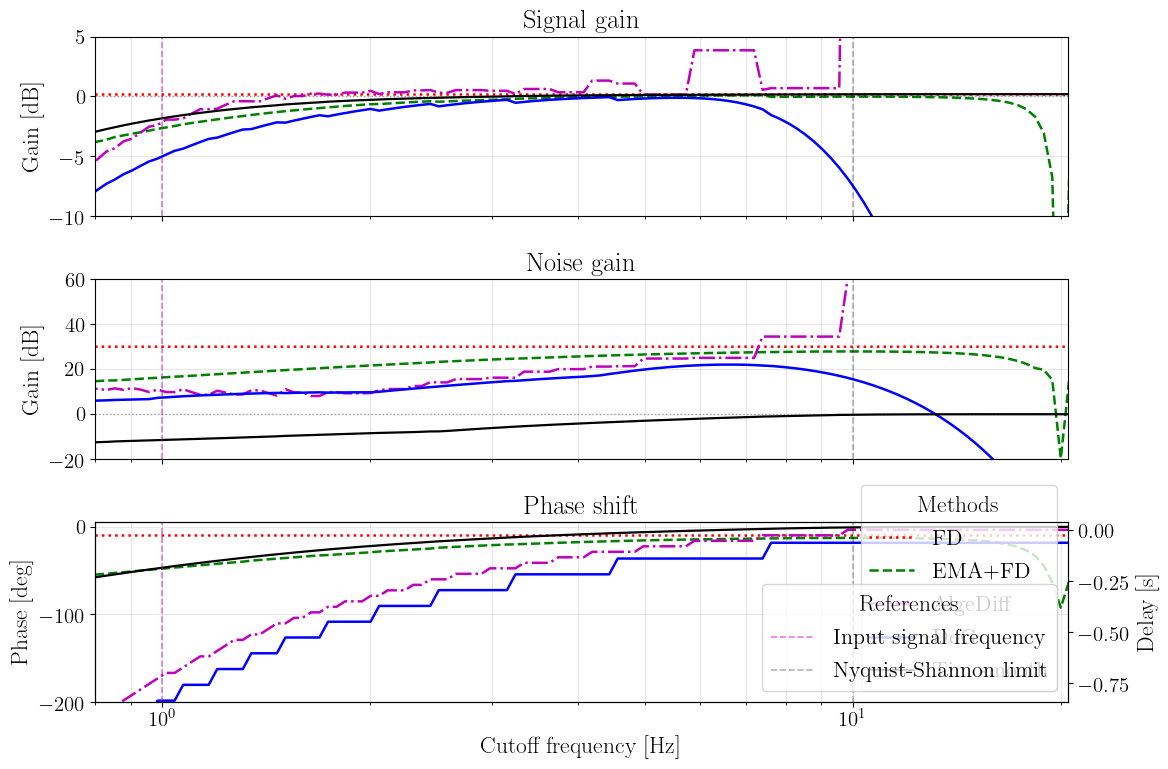

In [396]:
# Plot signal gain (upper), noise gain (middle), and phase+delay (lower)
fig, (ax_sig, ax_mag, ax_phase) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

plt.xlim([0.8,f_s_phase + 0.025 *f_s_phase])
# Upper panel: Signal gain
ax_sig.semilogx(f_cut_vals, amplitude_ratio_vals_fd, 'r:', linewidth=1.8, label='FD')
ax_sig.semilogx(f_cut_vals, amplitude_ratio_vals_ma_fd, 'g--', linewidth=1.8, label='MA+FD')
ax_sig.semilogx(f_cut_vals, amplitude_ratio_vals_alge, 'm-.', linewidth=1.8, label='AlgeDiff')
ax_sig.semilogx(f_cut_vals, amplitude_ratio_vals_dog, 'b-', linewidth=1.8, label='DoG')
ax_sig.semilogx(f_cut_vals, amplitude_ratio_vals_tim, 'k-', linewidth=1.6, label='Tim smooth')
ax_sig.axvline(f_input, color='m', linestyle='--', linewidth=1.2, alpha=0.5)
ax_sig.axvline(f_s_phase / 2, color='k', linestyle='--', linewidth=1.2, alpha=0.3, label='Nyquist-Shannon limit')
ax_sig.axhline(20*np.log10(1.0), color='k', linestyle=':', linewidth=1.0, alpha=0.3)
ax_sig.grid(True, which='both', alpha=0.3)
ax_sig.set_ylabel('Gain [dB]')
ax_sig.set_ylim([-10, 5])
ax_sig.set_title('Signal gain')
#ax_sig.legend(loc='best', fontsize=9)

# Middle panel: Noise gain
ax_mag.semilogx(f_cut_vals, noise_amplitude_factor_vals_fd, 'r:', linewidth=1.8, label='FD')
ax_mag.semilogx(f_cut_vals, noise_amplitude_factor_vals_ma_fd, 'g--', linewidth=1.8, label='MA+FD')
ax_mag.semilogx(f_cut_vals, noise_amplitude_factor_vals_alge, 'm-.', linewidth=1.8, label='AlgeDiff')
ax_mag.semilogx(f_cut_vals, noise_amplitude_factor_vals_dog, 'b-', linewidth=1.8, label='DoG')
ax_mag.semilogx(f_cut_vals, noise_amplitude_factor_vals_tim, 'k-', linewidth=1.6, label='Tim smooth')
ax_mag.axvline(f_input, color='m', linestyle='--', linewidth=1.2, alpha=0.5)
ax_mag.axvline(f_s_phase / 2, color='k', linestyle='--', linewidth=1.2, alpha=0.3, label='Nyquist-Shannon limit')
ax_mag.axhline(20*np.log10(1.0), color='k', linestyle=':', linewidth=1.0, alpha=0.3)
ax_mag.grid(True, which='both', alpha=0.3)
ax_mag.set_ylabel('Gain [dB]')
ax_mag.set_ylim([-20, 60])
ax_mag.set_title('Noise gain')
#ax_mag.legend(loc='best', fontsize=9)

# Lower panel: Phase shift
ax_phase.semilogx(f_cut_vals, phase_shift_deg_vals_fd, 'r:', linewidth=1.8, label='FD')
ax_phase.semilogx(f_cut_vals, phase_shift_deg_vals_ma_fd, 'g--', linewidth=1.8, label='MA+FD')
ax_phase.semilogx(f_cut_vals, phase_shift_deg_vals_alge, 'm-.', linewidth=1.8, label='AlgeDiff')
ax_phase.semilogx(f_cut_vals, phase_shift_deg_vals_dog, 'b-', linewidth=1.8, label='DoG')
ax_phase.semilogx(f_cut_vals, phase_shift_deg_vals_tim, 'k-', linewidth=1.6, label='Tim smooth')
ax_phase.axvline(f_input, color='m', linestyle='--', linewidth=1.2, alpha=0.5, label='Input signal frequency')
ax_phase.axvline(f_s_phase / 2, color='k', linestyle='--', linewidth=1.2, alpha=0.3, label='Nyquist-Shannon limit')
ax_phase.grid(True, which='both', alpha=0.3)
ax_phase.set_ylabel('Phase [deg]')
ax_phase.set_ylim([-200, 5])
ax_phase.set_xlabel('Cutoff frequency [Hz]')
ax_phase.set_title('Phase shift')

# Add delay axis (invisible line, no legend entry)
ax_delay = ax_phase.twinx()
ax_delay.semilogx(f_cut_vals, delay_vals, color='none')  # Invisible line
ax_delay.set_ylabel('Delay [s]')

# First legend (method lines)
lines = ax_phase.get_lines()[:5]  # FD, MA+FD, AlgeDiff, DoG, Tim smooth
legend1 = ax_phase.legend(lines, ['FD', 'EMA+FD', 'AlgeDiff', 'DoG', 'Tim smooth'], loc='lower right', title='Methods')

# Second legend (vertical lines)
lines2 = ax_phase.get_lines()[5:]  # Input frequency, Nyquist limit
legend2 = ax_phase.legend(lines2, ['Input signal frequency', 'Nyquist-Shannon limit'], title='References')

ax_phase.add_artist(legend1)
#ax_phase.legend(loc='best')

plt.tight_layout()
if save_to_disk:
    plt.savefig('/home/fabi/catkin_ws/src/ros_imu_calib/pub/img/bode.eps', format='eps', dpi=600)
plt.show()